# 03 Exploratory Data Analysis

## Loan Default Prediction and Credit Risk Scorecard

This notebook analyzes default patterns across borrower, loan, and credit profile segments. The goal is to identify business-relevant risk drivers before machine learning modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

df = pd.read_csv("../data/processed/loan_modeling_dataset.csv")

df.shape

(1369566, 37)

In [2]:
df.head()

,loan_amnt,funded_amnt,term_months,int_rate,installment,grade,sub_grade,grade_risk_numeric,emp_length_years,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,application_type,mort_acc,pub_rec_bankruptcies,issue_year,issue_month,credit_history_months,loan_income_ratio,installment_income_ratio,high_dti_flag,high_revol_util_flag,recent_inquiry_flag,long_term_flag,income_band,dti_band,credit_history_band,default_flag
0,3600.0,3600.0,36,13.99,123.03,C,C4,3,10.0,MORTGAGE,55000.0,Not Verified,debt_consolidation,5.91,0.0,1.0,7.0,0.0,2765.0,29.7,13.0,Individual,1.0,0.0,2015,12,148.0,0.065455,0.026843,0,0,0,0,Middle Income,Low DTI,Established Credit History,0
1,24700.0,24700.0,36,11.99,820.28,C,C1,3,10.0,MORTGAGE,65000.0,Not Verified,small_business,16.06,1.0,4.0,22.0,0.0,21470.0,19.2,38.0,Individual,4.0,0.0,2015,12,192.0,0.380000,0.151436,0,0,1,0,Middle Income,Moderate DTI,Long Credit History,0
2,20000.0,20000.0,60,10.78,432.66,B,B4,2,10.0,MORTGAGE,63000.0,Not Verified,home_improvement,10.78,0.0,0.0,6.0,0.0,7869.0,56.2,18.0,Joint App,5.0,0.0,2015,12,184.0,0.317460,0.082411,0,0,0,1,Middle Income,Moderate DTI,Long Credit History,0
3,10400.0,10400.0,60,22.45,289.91,F,F1,6,3.0,MORTGAGE,104433.0,Source Verified,major_purchase,25.37,1.0,3.0,12.0,0.0,21929.0,64.5,35.0,Individual,6.0,0.0,2015,12,210.0,0.099585,0.033312,0,0,1,1,Upper Middle Income,High DTI,Long Credit History,0
4,11950.0,11950.0,36,13.44,405.18,C,C3,3,4.0,RENT,34000.0,Source Verified,debt_consolidation,10.20,0.0,0.0,5.0,0.0,8822.0,68.4,6.0,Individual,0.0,0.0,2015,12,338.0,0.351471,0.143005,0,0,0,0,Low Income,Moderate DTI,Long Credit History,0


In [ ]:
df.info()

In [3]:
df["default_flag"].value_counts()

default_flag
0    1078739
1     290827
Name: count, dtype: int64

In [4]:
df["default_flag"].value_counts(normalize=True).mul(100).round(2)

default_flag
0    78.77
1    21.23
Name: proportion, dtype: float64

## Initial EDA Observation

The modeling dataset contains completed loan outcomes only. The target variable is moderately imbalanced, with non-default loans representing the majority class and default loans representing the minority class.

In [6]:
def default_rate_table(data, group_col):
    summary = (
        data.groupby(group_col)
        .agg(
            loan_count=("default_flag", "count"),
            default_count=("default_flag", "sum"),
            default_rate=("default_flag", "mean")
        )
        .reset_index()
    )
    
    summary["default_rate_pct"] = (summary["default_rate"] * 100).round(2)
    summary = summary.sort_values("default_rate", ascending=False)
    
    return summary

In [7]:
overall_default_rate = df["default_flag"].mean()

print(f"Overall Default Rate: {overall_default_rate:.2%}")

Overall Default Rate: 21.23%


In [8]:
default_by_grade = default_rate_table(df, "grade").sort_values("grade")

default_by_grade

,grade,loan_count,default_count,default_rate,default_rate_pct
0,A,236515,15536,0.065687,6.57
1,B,397890,57449,0.144384,14.44
2,C,389877,93359,0.239458,23.95
3,D,206418,66025,0.319861,31.99
4,E,96358,38365,0.398151,39.82
5,F,32946,15225,0.462120,46.21
6,G,9562,4868,0.509099,50.91


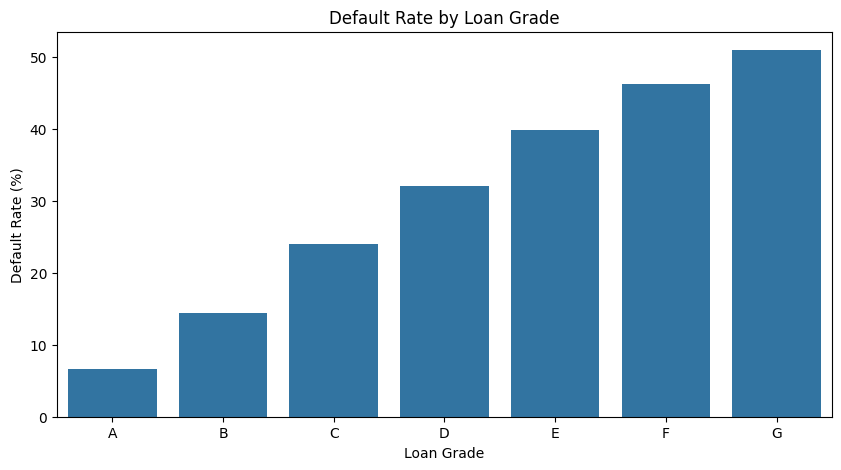

In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(data=default_by_grade, x="grade", y="default_rate_pct")
plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate (%)")
plt.show()

## Business Interpretation: Loan Grade

Default risk increases as loan grade weakens. This confirms that loan grade is a strong risk indicator and should be included in modeling and dashboard segmentation.

In [10]:
default_by_sub_grade = default_rate_table(df, "sub_grade").sort_values("sub_grade")

default_by_sub_grade.head()

,sub_grade,loan_count,default_count,default_rate,default_rate_pct
0,A1,43827,1554,0.035458,3.55
1,A2,37377,1924,0.051476,5.15
2,A3,38255,2339,0.061142,6.11
3,A4,52588,3921,0.074561,7.46
4,A5,64468,5798,0.089936,8.99


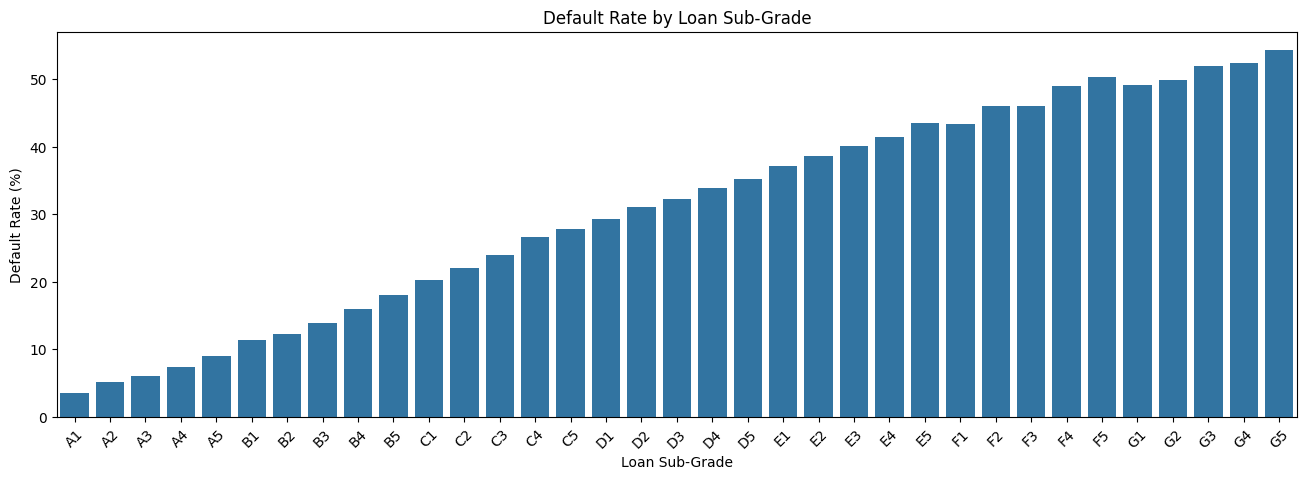

In [11]:
plt.figure(figsize=(16, 5))
sns.barplot(data=default_by_sub_grade, x="sub_grade", y="default_rate_pct")
plt.title("Default Rate by Loan Sub-Grade")
plt.xlabel("Loan Sub-Grade")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [12]:
default_by_term = default_rate_table(df, "term_months").sort_values("term_months")

default_by_term

,term_months,loan_count,default_count,default_rate,default_rate_pct
0,36,1035680,176400,0.170323,17.03
1,60,333886,114427,0.342713,34.27


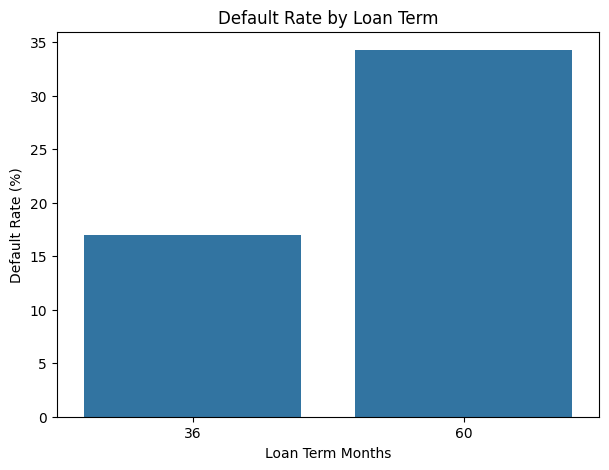

In [13]:
plt.figure(figsize=(7, 5))
sns.barplot(data=default_by_term, x="term_months", y="default_rate_pct")
plt.title("Default Rate by Loan Term")
plt.xlabel("Loan Term Months")
plt.ylabel("Default Rate (%)")
plt.show()

## Business Interpretation: Loan Term

Longer-term loans typically show higher default risk because borrowers are exposed to repayment uncertainty for a longer period. This feature is relevant for underwriting and risk segmentation.

In [14]:
default_by_dti_band = default_rate_table(df, "dti_band")

default_by_dti_band

,dti_band,loan_count,default_count,default_rate,default_rate_pct
3,Very High DTI,131370,40501,0.308297,30.83
0,High DTI,415722,100996,0.242941,24.29
2,Moderate DTI,571316,108644,0.190164,19.02
1,Low DTI,250760,40591,0.161872,16.19


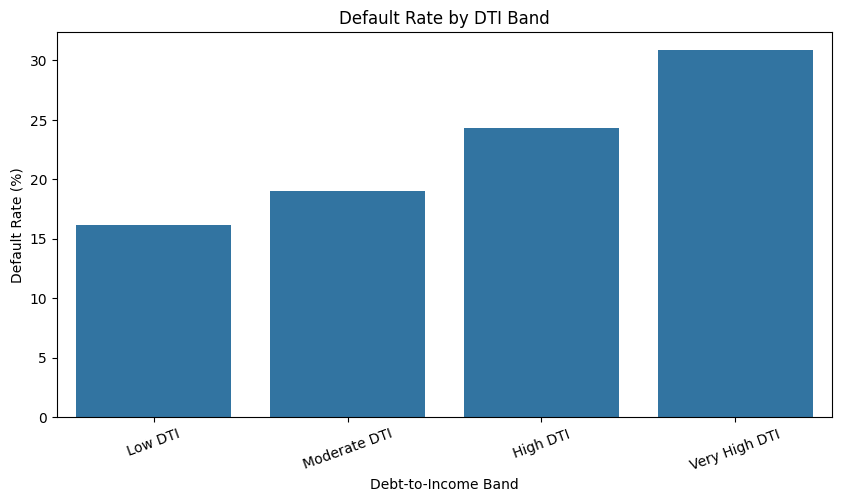

In [15]:
dti_order = ["Low DTI", "Moderate DTI", "High DTI", "Very High DTI"]

default_by_dti_band["dti_band"] = pd.Categorical(
    default_by_dti_band["dti_band"],
    categories=dti_order,
    ordered=True
)

default_by_dti_band = default_by_dti_band.sort_values("dti_band")

plt.figure(figsize=(10, 5))
sns.barplot(data=default_by_dti_band, x="dti_band", y="default_rate_pct")
plt.title("Default Rate by DTI Band")
plt.xlabel("Debt-to-Income Band")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20)
plt.show()

## Business Interpretation: DTI

Borrowers with higher debt-to-income ratios tend to show higher repayment risk. DTI is a key borrower capacity measure and should be monitored in both modeling and dashboard reporting.

In [16]:
default_by_income_band = default_rate_table(df, "income_band")

default_by_income_band

,income_band,loan_count,default_count,default_rate,default_rate_pct
1,Low Income,250510,62371,0.248976,24.90
2,Middle Income,674596,148411,0.220000,22.00
3,Upper Middle Income,292573,54652,0.186798,18.68
0,High Income,151499,25302,0.167011,16.70


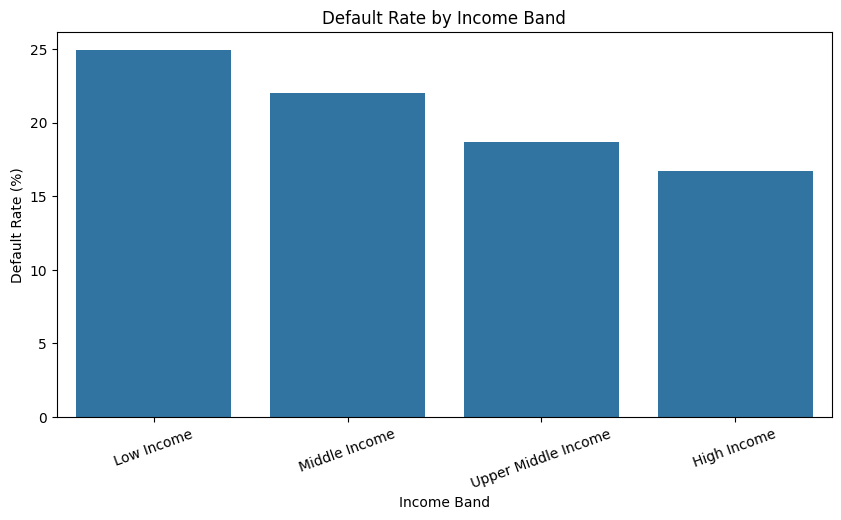

In [17]:
income_order = ["Low Income", "Middle Income", "Upper Middle Income", "High Income"]

default_by_income_band["income_band"] = pd.Categorical(
    default_by_income_band["income_band"],
    categories=income_order,
    ordered=True
)

default_by_income_band = default_by_income_band.sort_values("income_band")

plt.figure(figsize=(10, 5))
sns.barplot(data=default_by_income_band, x="income_band", y="default_rate_pct")
plt.title("Default Rate by Income Band")
plt.xlabel("Income Band")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [18]:
default_by_purpose = default_rate_table(df, "purpose")

default_by_purpose

,purpose,loan_count,default_count,default_rate,default_rate_pct
11,small_business,15916,4991,0.313584,31.36
10,renewable_energy,950,236,0.248421,24.84
8,moving,9704,2407,0.248042,24.80
5,house,7485,1786,0.238611,23.86
7,medical,15908,3705,0.232902,23.29
9,other,79905,18112,0.226669,22.67
2,debt_consolidation,793917,177802,0.223955,22.40
3,educational,423,88,0.208038,20.80
12,vacation,9245,1905,0.206057,20.61
6,major_purchase,30118,6066,0.201408,20.14


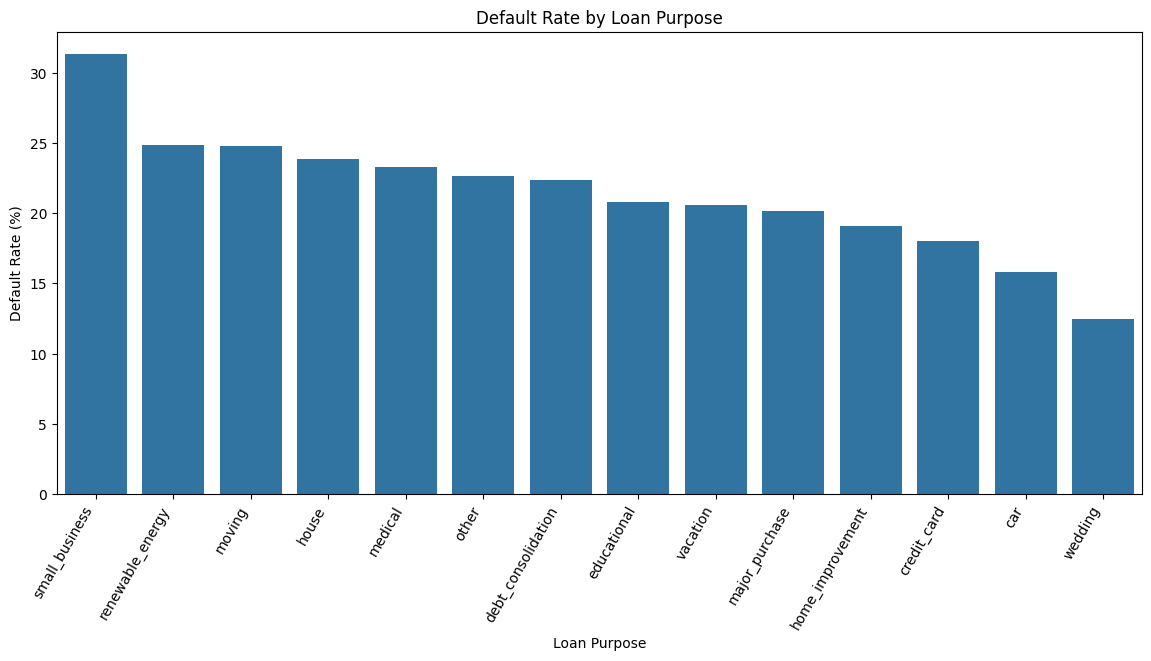

In [19]:
plt.figure(figsize=(14, 6))
sns.barplot(data=default_by_purpose, x="purpose", y="default_rate_pct")
plt.title("Default Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=60, ha="right")
plt.show()

## Business Interpretation: Loan Purpose

Default risk varies by loan purpose. This can help risk teams monitor borrower intent and identify purpose categories that may require closer review.

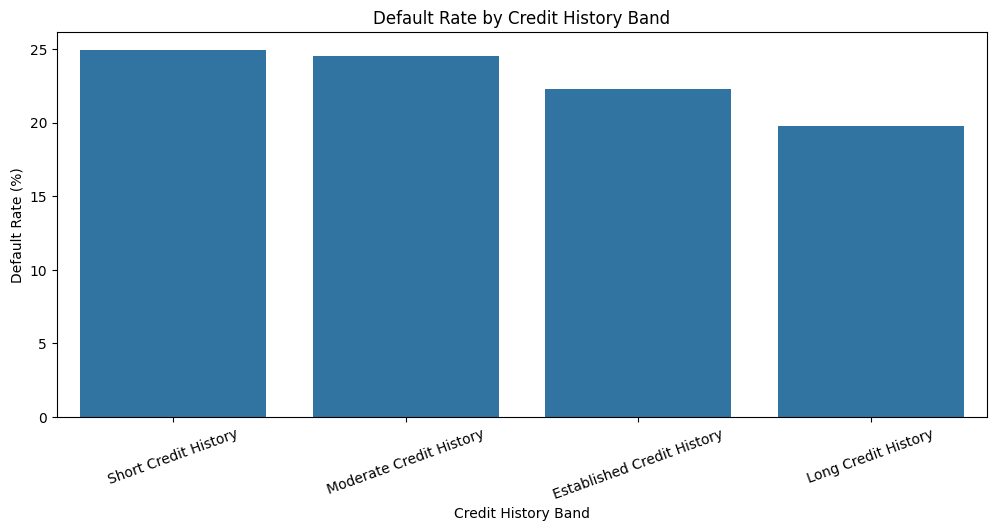

In [22]:
default_by_credit_history = default_rate_table(df, "credit_history_band")

default_by_credit_history

credit_history_order = [
    "Short Credit History",
    "Moderate Credit History",
    "Established Credit History",
    "Long Credit History"
]

default_by_credit_history["credit_history_band"] = pd.Categorical(
    default_by_credit_history["credit_history_band"],
    categories=credit_history_order,
    ordered=True
)

default_by_credit_history = default_by_credit_history.sort_values("credit_history_band")

plt.figure(figsize=(12, 5))
sns.barplot(data=default_by_credit_history, x="credit_history_band", y="default_rate_pct")
plt.title("Default Rate by Credit History Band")
plt.xlabel("Credit History Band")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [23]:
numeric_features = [
    "loan_amnt",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "revol_util",
    "loan_income_ratio",
    "installment_income_ratio",
    "credit_history_months"
]

numeric_features = [col for col in numeric_features if col in df.columns]

df[numeric_features].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
loan_amnt,1369566.0,14448.774283,8737.506570,500.000000,1500.000000,3200.000000,12000.000000,33000.000000,35000.000000,40000.000000
int_rate,1369566.0,13.279112,4.784094,5.310000,5.320000,6.540000,12.790000,22.200000,26.490000,30.990000
installment,1369566.0,438.759304,262.010546,4.930000,52.873000,108.810000,375.430000,964.665000,1223.430000,1719.830000
annual_inc,1369562.0,74624.733887,42225.204246,18000.000000,18000.000000,28000.000000,65000.000000,155000.000000,252000.000000,252000.000000
dti,1369168.0,18.147035,8.446163,1.760000,1.760000,4.960000,17.620000,33.020000,38.560000,38.560000
revol_util,1368642.0,51.760655,24.457654,1.100000,1.100000,10.300000,52.100000,91.500000,98.200000,98.200000
loan_income_ratio,1369178.0,0.213798,0.113971,0.025600,0.025600,0.052583,0.200000,0.430769,0.500000,0.500000
installment_income_ratio,1369178.0,0.078953,0.042575,0.010204,0.010204,0.020532,0.072276,0.159973,0.201103,0.201103
credit_history_months,1369537.0,194.437836,88.042237,46.000000,46.000000,74.000000,177.000000,369.000000,478.000000,478.000000


## Business Interpretation: Interest Rate

Defaulted loans tend to have higher interest rates. This is expected because pricing often reflects borrower risk. However, interest rate should be used carefully because it may partially reflect the lender's internal risk assessment.

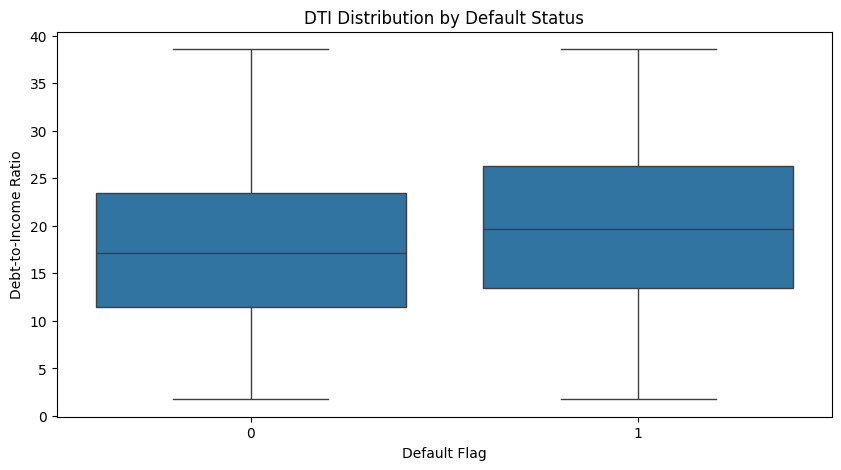

In [24]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="default_flag", y="dti")
plt.title("DTI Distribution by Default Status")
plt.xlabel("Default Flag")
plt.ylabel("Debt-to-Income Ratio")
plt.show()

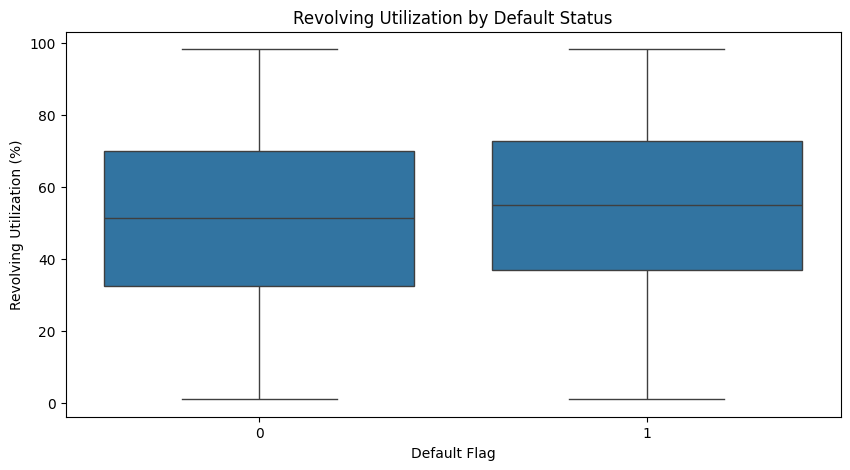

In [25]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="default_flag", y="revol_util")
plt.title("Revolving Utilization by Default Status")
plt.xlabel("Default Flag")
plt.ylabel("Revolving Utilization (%)")
plt.show()

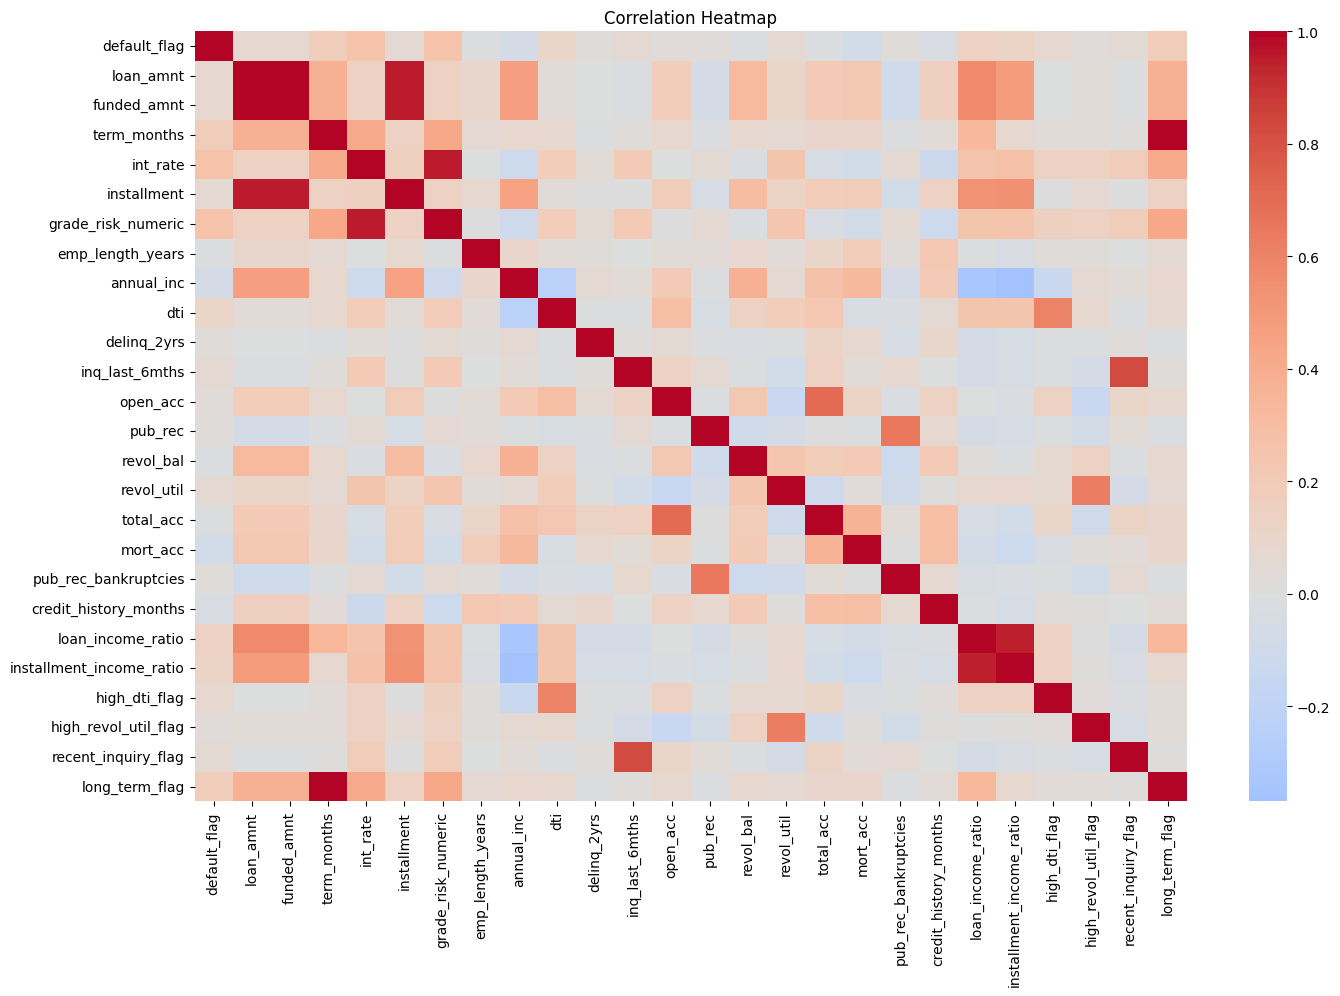

In [26]:
corr_cols = [
    "default_flag",
    "loan_amnt",
    "funded_amnt",
    "term_months",
    "int_rate",
    "installment",
    "grade_risk_numeric",
    "emp_length_years",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "mort_acc",
    "pub_rec_bankruptcies",
    "credit_history_months",
    "loan_income_ratio",
    "installment_income_ratio",
    "high_dti_flag",
    "high_revol_util_flag",
    "recent_inquiry_flag",
    "long_term_flag"
]

corr_cols = [col for col in corr_cols if col in df.columns]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

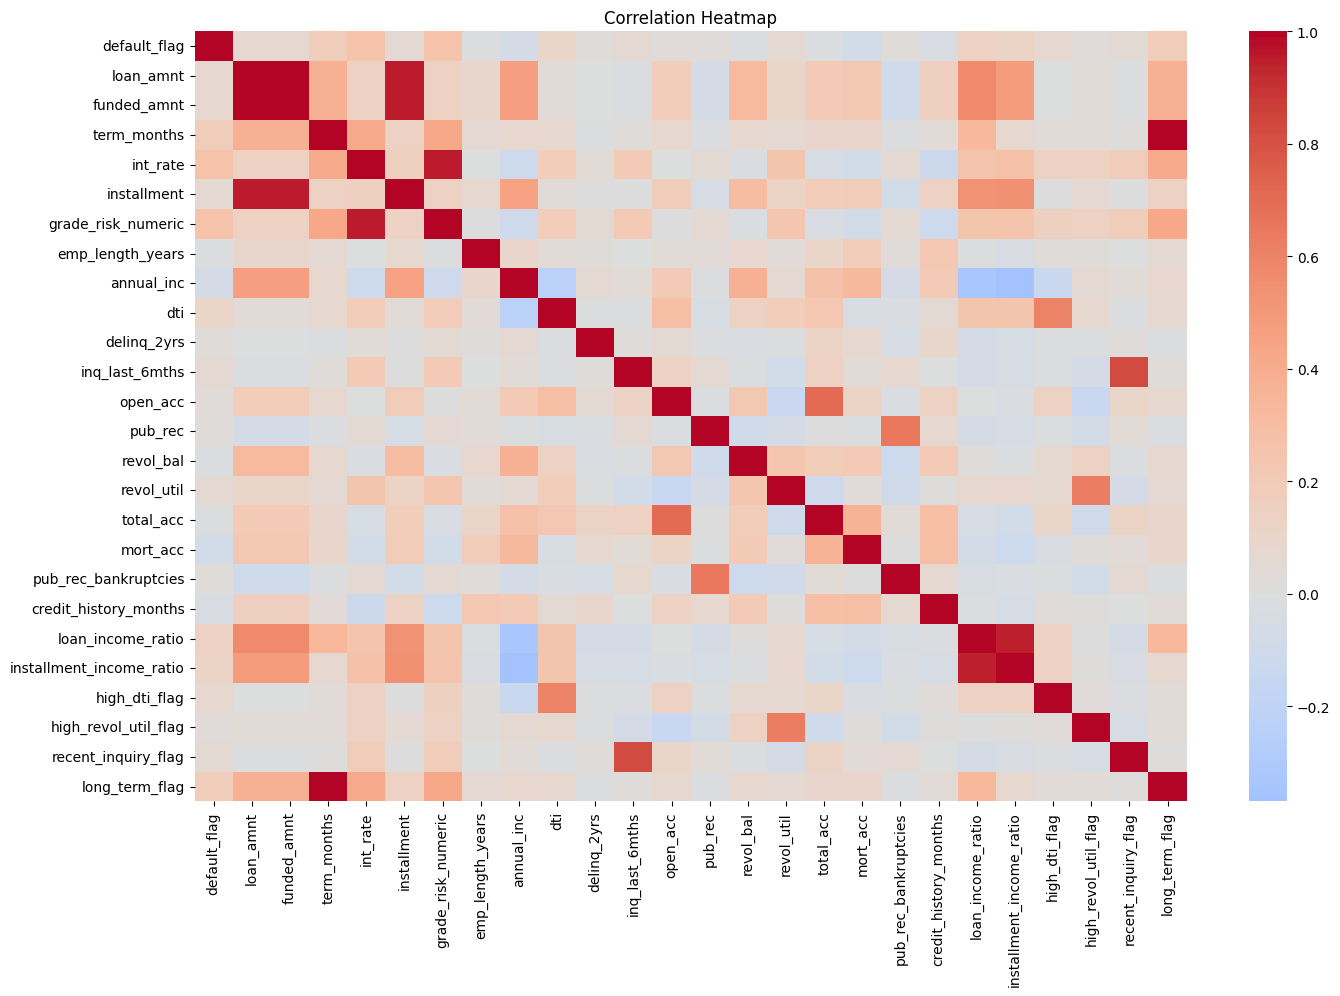

In [27]:
corr_cols = [
    "default_flag",
    "loan_amnt",
    "funded_amnt",
    "term_months",
    "int_rate",
    "installment",
    "grade_risk_numeric",
    "emp_length_years",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "mort_acc",
    "pub_rec_bankruptcies",
    "credit_history_months",
    "loan_income_ratio",
    "installment_income_ratio",
    "high_dti_flag",
    "high_revol_util_flag",
    "recent_inquiry_flag",
    "long_term_flag"
]

corr_cols = [col for col in corr_cols if col in df.columns]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [28]:
default_by_grade.to_csv("../data/outputs/eda_default_by_grade.csv", index=False)
default_by_sub_grade.to_csv("../data/outputs/eda_default_by_sub_grade.csv", index=False)
default_by_term.to_csv("../data/outputs/eda_default_by_term.csv", index=False)
default_by_dti_band.to_csv("../data/outputs/eda_default_by_dti_band.csv", index=False)
default_by_income_band.to_csv("../data/outputs/eda_default_by_income_band.csv", index=False)
default_by_purpose.to_csv("../data/outputs/eda_default_by_purpose.csv", index=False)
default_by_credit_history.to_csv("../data/outputs/eda_default_by_credit_history.csv", index=False)

print("EDA summary tables saved.")

EDA summary tables saved.


# EDA Summary

## Key Business Findings

- Default risk varies significantly across borrower and loan characteristics.
- Loan grade, sub-grade, interest rate, term, DTI, revolving utilization, and loan burden ratios are strong candidate risk indicators.
- Longer-term loans and higher debt burden segments appear riskier.
- The EDA supports building machine learning models that combine borrower capacity, credit history, loan structure, and application profile variables.

## Next Step

The next notebook will build the first machine learning models: naive baseline, logistic regression, and regularized logistic regression.